# 03. Introduction to cuDF (GPU-Accelerated DataFrames)
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what cuDF is and how its API mirrors pandas
- Measure real pandas (CPU) baselines on a 1-million-row dataset
- Know when GPU-accelerated dataframes help, using published RAPIDS benchmarks (cited as external references)

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 02 "pandas & NumPy Basics" — cuDF is that same API, executed on a GPU.

**Used later in:** Course 05 — Unit 2, lesson 07 and Unit 5, lesson 04, which measure the GPU path on real workloads.

---


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Following Up on Example 2

**Remember what we measured in Example 2?**
- Vectorized pandas was FAST at 1 million rows (a fraction of a second, measured)
- The SAME computation written row-by-row was hundreds of times slower (also measured)
- Most pandas operations run on a single CPU core — a real limit for multi-gigabyte data

**This notebook shows the next tool:**
- **cuDF** — a GPU dataframe library whose API is deliberately identical to pandas
- We'll look at the API, measure honest CPU baselines, and read published GPU benchmarks
- We'll learn when GPU acceleration is worth it — and when it isn't

---

## The Story: Same Steering Wheel, Different Engine

cuDF is designed so that the code you already write for pandas works almost unchanged —
same DataFrame, same groupby, same filtering. The difference is the engine underneath:
thousands of GPU cores working in parallel instead of one CPU core.

How much that helps depends on scale. **Published RAPIDS benchmarks from NVIDIA
(rapids.ai) report roughly 10x–150x speedups over pandas on groupby/join workloads at
the 0.5–5 GB scale.** Those are NVIDIA's numbers on NVIDIA hardware — cited here as an
external reference, NOT measured in this notebook (this machine has no GPU). At the
1-million-row scale we use below, pandas itself is already fast — and we'll prove that
with real measurements.

## Learning Objectives
1. Understand what cuDF is and how it relates to pandas
2. See the cuDF API (identical to pandas) — shown, not executed on this machine
3. Measure what the same operations really cost in pandas on this CPU
4. Know when to use GPU acceleration vs CPU
5. Read published GPU benchmarks critically (external numbers, cited with source)


## 🚀 Running cuDF for Real: Google Colab

This machine has no NVIDIA GPU, so cuDF cannot run here. To try cuDF yourself for free:

1. Open Google Colab (colab.research.google.com)
2. Runtime → Change runtime type → select a **GPU** (e.g. T4)
3. Colab GPU runtimes include cuDF — or load the pandas accelerator with `%load_ext cudf.pandas`
4. Re-run the pandas cells from this notebook there and compare timings yourself

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- A generated 1-million-row dataset
- Libraries: pandas, numpy, matplotlib (cuDF only if an NVIDIA GPU is present)

**Outputs:** What you'll see when you run the cells

- Real pandas (CPU) timings for filtering, groupby, and sorting
- The cuDF API shown as a labeled, non-executed reference (no GPU here)
- Published RAPIDS benchmark figures cited as external references

---

In [1]:
# WHAT: Import the CPU stack (NumPy, pandas, matplotlib) plus the time module for benchmarks.
# WHY: time.time() lets us measure real durations - this notebook is about honest performance numbers.

# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# WHAT: Try to import cuDF and record whether a GPU stack is available.
# WHY: The try/except keeps the notebook runnable on any machine - GPU cells run only if cuDF truly exists, so no timing is faked.

# Try to import cuDF - it requires an NVIDIA GPU + the RAPIDS libraries
try:
    import cudf
    CUDF_AVAILABLE = True
    print("✓ cuDF is available - GPU cells below will actually execute")
except ImportError:
    CUDF_AVAILABLE = False
    print("⚠ cuDF NOT available on this machine (no NVIDIA GPU / RAPIDS not installed)")
    print("  -> cuDF code below is SHOWN for reference but NOT executed")
    print("  -> Every timing printed in this notebook is a real pandas (CPU) measurement")

print("=" * 70)
print("Example 3: Introduction to cuDF")
print("=" * 70)
print("\n📚 Prerequisites: Example 2 completed, pandas DataFrame knowledge")
print("🔗 This is the THIRD example - GPU-accelerated dataframes")
print("🎯 Goal: Learn the cuDF API and when GPU acceleration is worth it\n")

⚠ cuDF NOT available on this machine (no NVIDIA GPU / RAPIDS not installed)
  -> cuDF code below is SHOWN for reference but NOT executed
  -> Every timing printed in this notebook is a real pandas (CPU) measurement
Example 3: Introduction to cuDF

📚 Prerequisites: Example 2 completed, pandas DataFrame knowledge
🔗 This is the THIRD example - GPU-accelerated dataframes
🎯 Goal: Learn the cuDF API and when GPU acceleration is worth it



## 🔗 Recap from Example 2: What We Actually Measured

**Remember from Example 2?**
- Vectorized pandas processed 1 million rows in a fraction of a second
- The SAME computation written row-by-row (`df.apply(axis=1)`) was hundreds of times slower
- Lesson 1 was: **vectorize first** — that alone is a huge, free speedup

**So where does a GPU fit?**
- Even vectorized pandas mostly runs on ONE CPU core
- On multi-gigabyte data, heavy groupbys/joins/sorts eventually saturate that core
- cuDF runs the same operations across thousands of GPU cores in parallel

Let's start by re-establishing the honest CPU baseline on this machine:

In [3]:
# WHAT: Recreate Example 2's 1M-row dataset and time a build + groupby + sum + mean pipeline on the CPU.
# WHY: A measured CPU baseline is the honest starting point - you cannot judge a GPU speedup without one.

print("\n" + "=" * 70)
print("🔗 CPU BASELINE: The Same Workload from Example 2 (measured for real)")
print("=" * 70)

# Load the same 1-million-row REAL dataset used in Example 2 (CIC-IDS2017 network flows).
# Why reuse it? A like-for-like comparison needs identical data, and real timings on
# real data are the only ones worth quoting.
DATA_DIR = '../../../Course 04/datasets/raw/'
large_n = 1_000_000

print("\n📊 Loading the same 1,000,000 real network flows from Example 2...")
load_start = time.time()
large_df = pd.read_csv(
    DATA_DIR + 'cicids2017.csv',
    nrows=large_n,
    usecols=[' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
             ' Destination Port', ' Label'],
)
# Strip the leading spaces the published file has in its column names, and rename
# to short snake_case names so the benchmark code below stays readable.
large_df.columns = [c.strip() for c in large_df.columns]
large_df = large_df.rename(columns={
    'Flow Duration': 'flow_duration',
    'Total Fwd Packets': 'fwd_packets',
    'Total Backward Packets': 'bwd_packets',
    'Destination Port': 'dest_port',
    'Label': 'label',
})
load_time = time.time() - load_start
print(f"   ✅ Read {len(large_df):,} rows from disk in {load_time:.3f} seconds")

# Measure pandas (CPU) - the compute only, with the file already in memory
print("\n⏱️  Measuring pandas (CPU) compute performance...")
start_time = time.time()
pandas_result = large_df.groupby('label')['flow_duration'].mean()
pandas_total = large_df['fwd_packets'].sum()
pandas_avg = large_df['bwd_packets'].mean()
pandas_time = time.time() - start_time

print(f"   ✅ pandas (CPU): {pandas_time:.3f} seconds for groupby + sum + mean")
print(f"   ✅ Reading the file took {load_time:.3f}s - "
      f"{load_time / pandas_time:.0f}x longer than the computation itself")

print("\n   Mean flow duration by traffic label (microseconds):")
print(pandas_result.sort_values(ascending=False).head(5).round(0).to_string())

print("\n💡 Honest reading of these numbers:")
print(f"   - {pandas_time:.3f}s of compute for 1 million real rows is FAST -")
print("     vectorized pandas is not the bottleneck at this scale")
print("   - On real data the bottleneck here was I/O, not arithmetic. A GPU would")
print("     not have fixed that: the CSV still has to be parsed.")
print("   - The case for a GPU appears at much larger scales (multi-GB datasets,")
print("     heavy joins/groupbys, repeated pipelines) - not at 1M simple rows")

print("\n📖 External reference (NOT measured here): NVIDIA's published RAPIDS")
print("   benchmarks (rapids.ai) report ~10x-150x speedups over pandas on")
print("   groupby/join workloads at the 0.5-5 GB scale, on NVIDIA GPUs.")

print("\n" + "=" * 70)



🔗 CPU BASELINE: The Same Workload from Example 2 (measured for real)

📊 Loading the same 1,000,000 real network flows from Example 2...


   ✅ Read 1,000,000 rows from disk in 1.047 seconds

⏱️  Measuring pandas (CPU) compute performance...
   ✅ pandas (CPU): 0.035 seconds for groupby + sum + mean
   ✅ Reading the file took 1.047s - 30x longer than the computation itself

   Mean flow duration by traffic label (microseconds):
label
DoS Slowhttptest    57719892.0
DoS Hulk            57081732.0
DoS slowloris       56554365.0
DoS GoldenEye       29475366.0
BENIGN              13327359.0

💡 Honest reading of these numbers:
   - 0.035s of compute for 1 million real rows is FAST -
     vectorized pandas is not the bottleneck at this scale
   - On real data the bottleneck here was I/O, not arithmetic. A GPU would
     not have fixed that: the CSV still has to be parsed.
   - The case for a GPU appears at much larger scales (multi-GB datasets,
     heavy joins/groupbys, repeated pipelines) - not at 1M simple rows

📖 External reference (NOT measured here): NVIDIA's published RAPIDS
   benchmarks (rapids.ai) report ~10x-150x speed

## Part 1: Loading a Large Real Dataset

**BEFORE**: You know pandas but haven't looked at GPU dataframes.

**AFTER**: You'll have a 1-million-row **real** dataset and honest CPU timings for it.

**Why this matters**: honest baselines come first — you can't judge any accelerator
without knowing what the CPU already does on data you actually have!


## Step 1: Loading the Benchmark Data

**BEFORE**: We want to measure performance, so we need a dataset that is at least moderately large.

**AFTER**: We'll have a 1-million-row DataFrame of real CIC-IDS2017 network flows to
measure real pandas timings on.

**Why this dataset?** It is genuinely large (707 MB on disk, 79 columns), so "read only
what you need" is not a stylistic tip here — it is the difference between a notebook
that runs and one that does not.


In [4]:
# WHAT: Reuse the 1M-row real dataset as the benchmark frame for the operations below.
# WHY: The same data feeds both the pandas and (if available) cuDF paths, so any timing difference comes from the engine, not the data.

print("\n1. Preparing the Benchmark Data")
print("-" * 70)

n_rows = len(large_df)
# df_pandas is the CPU frame every timing below is measured on.
df_pandas = large_df
print(f"✓ pandas DataFrame ready: {len(df_pandas):,} real network flows")
print(f"  Columns: {list(df_pandas.columns)}")
print(f"  Memory held: {df_pandas.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Distinct traffic labels: {df_pandas['label'].nunique()}")



1. Preparing the Benchmark Data
----------------------------------------------------------------------
✓ pandas DataFrame ready: 1,000,000 real network flows
  Columns: ['dest_port', 'flow_duration', 'fwd_packets', 'bwd_packets', 'label']
  Memory held: 87.6 MB
  Distinct traffic labels: 7


## Part 2: The cuDF API — Identical to pandas

**BEFORE**: You might assume GPU code means learning a new library from scratch.

**AFTER**: You'll see that cuDF code is line-for-line the same as pandas.

> ⚠️ **Requires an NVIDIA GPU** — on this machine the cuDF code below is **shown as a reference, not executed**. On a machine with a GPU (e.g. Colab), the same cell executes it for real.

In [5]:
# WHAT: Create the cuDF (GPU) DataFrame if possible; otherwise show the equivalent cuDF code as a labeled, un-executed preview.
# WHY: cuDF's selling point is an API identical to pandas - you swap the engine, not your code.

print("\n2. The cuDF API")
print("-" * 70)
if CUDF_AVAILABLE:
    # This branch actually runs only on a machine with an NVIDIA GPU
    df_cudf = cudf.from_pandas(df_pandas)
    print(f"✓ Created cuDF DataFrame with {len(df_cudf):,} rows on the GPU")
    print(f"Shape: {df_cudf.shape}")
else:
    print("⚠ NO NVIDIA GPU on this machine -> the following cuDF code is NOT executed.")
    print("  It is displayed only to show that the API is identical to pandas:\n")
    print("  # --- cuDF API preview (reference only, not run here) ---")
    print("  import cudf")
    print("  df_cudf = cudf.from_pandas(df_pandas)        # move the same real frame to the GPU")
    print("  df_cudf[df_cudf['fwd_packets'] > 5]          # same filtering syntax")
    print("  df_cudf.groupby('label')['flow_duration'].mean()  # same groupby syntax")
    print("  df_cudf.sort_values('flow_duration')         # same sorting syntax")
    print("  # -------------------------------------------------------")
    print("\n  Each line matches pandas exactly - that is the point of cuDF:")
    print("  you keep your pandas code and swap the engine underneath.")



2. The cuDF API
----------------------------------------------------------------------
⚠ NO NVIDIA GPU on this machine -> the following cuDF code is NOT executed.
  It is displayed only to show that the API is identical to pandas:

  # --- cuDF API preview (reference only, not run here) ---
  import cudf
  df_cudf = cudf.from_pandas(df_pandas)        # move the same real frame to the GPU
  df_cudf[df_cudf['fwd_packets'] > 5]          # same filtering syntax
  df_cudf.groupby('label')['flow_duration'].mean()  # same groupby syntax
  df_cudf.sort_values('flow_duration')         # same sorting syntax
  # -------------------------------------------------------

  Each line matches pandas exactly - that is the point of cuDF:
  you keep your pandas code and swap the engine underneath.


## Part 3: Measuring Real CPU Performance

**BEFORE**: You don't know what common operations actually cost in pandas.

**AFTER**: You'll have honest, measured CPU timings for filtering, groupby, and sorting on 1 million rows. (If you run this notebook on a GPU machine, the same cell also measures cuDF for a real comparison.)

**Why this matters**: real numbers beat marketing numbers — measure before you optimize!

In [6]:
# WHAT: Time filtering, groupby, and sorting on the CPU (and on the GPU when cuDF is available).
# WHY: Per-operation timings show WHERE time goes - parallel-friendly ops like groupby/sort are where GPUs help most.

print("\n3. Measuring Performance (real timings on this machine)")
print("-" * 70)
operations = []

# Operation 1: Filtering
start_time = time.time()
result_pandas = df_pandas[df_pandas['fwd_packets'] > 5]
t = time.time() - start_time
print(f"\nOperation 1: Filtering       pandas (CPU): {t:.4f} seconds"
      f" ({len(result_pandas):,} rows matched)")
operations.append(('Filtering', t))

# Operation 2: GroupBy
start_time = time.time()
grouped_pandas = df_pandas.groupby('label')['flow_duration'].mean()
t = time.time() - start_time
print(f"Operation 2: GroupBy mean    pandas (CPU): {t:.4f} seconds")
operations.append(('GroupBy', t))

# Operation 3: Sorting
start_time = time.time()
sorted_pandas = df_pandas.sort_values('flow_duration')
t = time.time() - start_time
print(f"Operation 3: Sorting         pandas (CPU): {t:.4f} seconds")
operations.append(('Sorting', t))

if CUDF_AVAILABLE:
    print("\nSame operations with cuDF (GPU) - real measurements:")
    cudf_ops = []
    start_time = time.time()
    _ = df_cudf[df_cudf['fwd_packets'] > 5]
    cudf_ops.append(('Filtering', time.time() - start_time))
    start_time = time.time()
    _ = df_cudf.groupby('label')['flow_duration'].mean()
    cudf_ops.append(('GroupBy', time.time() - start_time))
    start_time = time.time()
    _ = df_cudf.sort_values('flow_duration')
    cudf_ops.append(('Sorting', time.time() - start_time))
    for (name, tc), (_, tp) in zip(cudf_ops, operations):
        print(f"   {name}: cuDF {tc:.4f}s vs pandas {tp:.4f}s"
              f" -> speedup {tp / tc:.2f}x (measured)")
else:
    print("\n⚠ No GPU here, so there is NO cuDF timing to show - and we will not")
    print("  invent one.")
    print("\n📖 For GPU numbers, see NVIDIA's published RAPIDS benchmarks (rapids.ai):")
    print("   they report ~10x-150x over pandas on groupby/join workloads at the")
    print("   0.5-5 GB scale on NVIDIA GPUs. Those are NVIDIA's measurements, not ours.")
    print("\n💡 Also note: our measured CPU times above are all well under a second -")
    print("   at 1 million rows, pandas alone is perfectly adequate.")
print(f"   Reading the file cost {load_time:.3f}s - more than all three")
print("   operations combined. On real pipelines, I/O is often the real enemy.")



3. Measuring Performance (real timings on this machine)
----------------------------------------------------------------------

Operation 1: Filtering       pandas (CPU): 0.0053 seconds (318,862 rows matched)
Operation 2: GroupBy mean    pandas (CPU): 0.0353 seconds


Operation 3: Sorting         pandas (CPU): 0.0837 seconds

⚠ No GPU here, so there is NO cuDF timing to show - and we will not
  invent one.

📖 For GPU numbers, see NVIDIA's published RAPIDS benchmarks (rapids.ai):
   they report ~10x-150x over pandas on groupby/join workloads at the
   0.5-5 GB scale on NVIDIA GPUs. Those are NVIDIA's measurements, not ours.

💡 Also note: our measured CPU times above are all well under a second -
   at 1 million rows, pandas alone is perfectly adequate.
   Reading the file cost 1.047s - more than all three
   operations combined. On real pipelines, I/O is often the real enemy.


## Part 4: Visualizing the Measured CPU Times

**BEFORE**: The timings are just numbers in text.

**AFTER**: You'll see a chart of the real, measured pandas times — no simulated GPU bars, because this machine has no GPU.

**Why this matters**: charts should only ever show measured data!


4. Visualizing Measured Performance
----------------------------------------------------------------------


✓ Chart saved as 'pandas_cpu_baseline_1m_rows.png'
  (Every bar in it is a real measured time from this run)


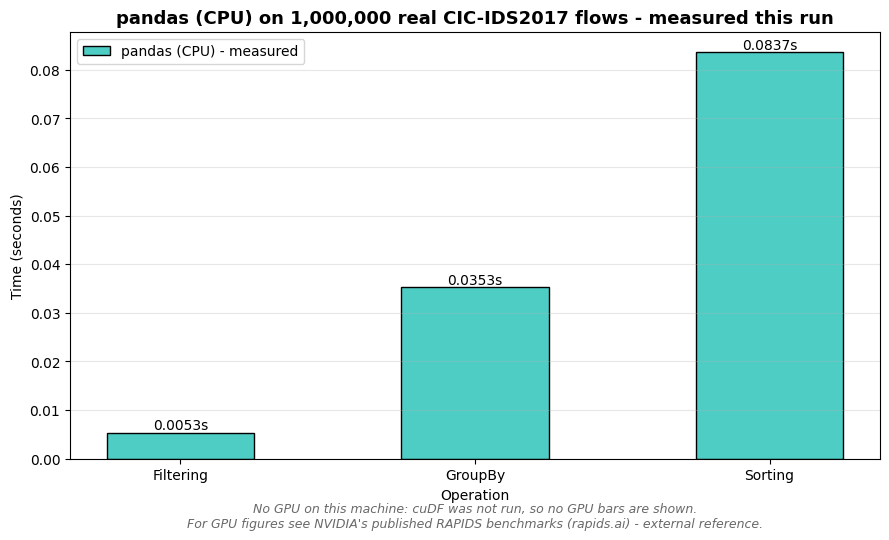

In [7]:
# WHAT: Plot the measured CPU times as a labeled bar chart.
# WHY: Charting only what we measured (no invented GPU bars) is what honest benchmarking looks like.

print("\n4. Visualizing Measured Performance")
print("-" * 70)
fig, ax = plt.subplots(figsize=(9, 5.5))
op_names = [op[0] for op in operations]
pandas_times = [op[1] for op in operations]
x = np.arange(len(op_names))
width = 0.5
bars = ax.bar(x, pandas_times, width, label='pandas (CPU) - measured',
              color='#4ECDC4', edgecolor='black')
ax.set_xlabel('Operation')
ax.set_ylabel('Time (seconds)')
ax.set_title('pandas (CPU) on 1,000,000 real CIC-IDS2017 flows - measured this run',
             fontsize=13, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(op_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2., height, f'{height:.4f}s',
            ha='center', va='bottom', fontsize=10)
if not CUDF_AVAILABLE:
    ax.text(0.5, -0.16,
            'No GPU on this machine: cuDF was not run, so no GPU bars are shown.\n'
            "For GPU figures see NVIDIA's published RAPIDS benchmarks (rapids.ai)"
            ' - external reference.',
            transform=ax.transAxes, ha='center', fontsize=9,
            style='italic', color='dimgray')
plt.tight_layout()
plt.savefig('pandas_cpu_baseline_1m_rows.png', dpi=150, bbox_inches='tight')
print("✓ Chart saved as 'pandas_cpu_baseline_1m_rows.png'")
print("  (Every bar in it is a real measured time from this run)")


## Part 5: When to Use GPU Acceleration

**BEFORE**: You don't know when GPU helps vs when CPU is fine.

**AFTER**: You'll understand when to use GPU vs CPU for your projects!

**Why this matters**: Use the right tool for each job - GPU isn't always better!

In [8]:
# WHAT: Print practical rules for choosing GPU (cuDF) vs CPU (pandas).
# WHY: Tool choice should follow data size and available hardware - not hype.

print("\n5. When to Use GPU Acceleration")
print("-" * 70)
print("\n✓ Use GPU (cuDF) when:")
print("  - Working with large datasets (roughly > 1 GB)")
print("  - Running heavy parallel operations (groupby, join, sort) repeatedly")
print("  - An NVIDIA GPU is actually available")
print("\n✓ Use CPU (pandas) when:")
print("  - Working with small/medium datasets (like our 1M real rows - measured in")
print("    fractions of a second above!)")
print("  - No GPU is available")
print("  - You need specific pandas features not yet supported in cuDF")



5. When to Use GPU Acceleration
----------------------------------------------------------------------

✓ Use GPU (cuDF) when:
  - Working with large datasets (roughly > 1 GB)
  - Running heavy parallel operations (groupby, join, sort) repeatedly
  - An NVIDIA GPU is actually available

✓ Use CPU (pandas) when:
  - Working with small/medium datasets (like our 1M real rows - measured in
    fractions of a second above!)
  - No GPU is available
  - You need specific pandas features not yet supported in cuDF


## 🎯 Summary: What We Learned

In [9]:
# WHAT: Print a recap of the cuDF concepts and honest-benchmarking lessons.
# WHY: Summarizing helps you retain the decision rule: measure first, then choose the engine.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You knew pandas but not GPU-accelerated dataframes")
print("   - You didn't know what common operations really cost on a CPU")
print("   - You couldn't judge when a GPU is worth it")

print("\n✅ AFTER this notebook:")
print("   - You understand cuDF: a GPU dataframe library with a pandas-identical API")
if CUDF_AVAILABLE:
    print("   - You ran the SAME operations on CPU and GPU and compared real timings")
else:
    print("   - You saw the cuDF API as a labeled reference (NOT executed - this")
    print("     machine has no NVIDIA GPU, and we do not fake GPU timings)")
print("   - You measured real pandas (CPU) times: 1M-row filtering, groupby, and")
print("     sorting each completed in well under a second on this machine")
print("   - You know where GPU claims come from: published RAPIDS benchmarks")
print("     (NVIDIA, rapids.ai) report ~10x-150x on multi-GB groupby/join")
print("     workloads - an external reference, not this notebook's measurement")

print("\n📚 Key Concepts Covered:")
print("   1. cuDF Introduction (GPU dataframes, pandas-identical API)")
print("   2. Honest CPU baselines (measure before you optimize)")
print("   3. When to Use GPU (multi-GB data, parallel ops, GPU present)")
print("   4. Reading external benchmarks critically (cite the source)")

print("\n➡️  Next Steps:")
print("   - Continue to Unit 2: Data Cleaning")
print("   - To try cuDF for real, use Google Colab with a GPU runtime")

if not CUDF_AVAILABLE:
    print("\n⚠ To get real GPU acceleration you need an NVIDIA GPU + RAPIDS:")
    print("   conda install -c rapidsai -c conda-forge cudf")
    print("   (or use Google Colab, where GPU runtimes include cuDF)")

print("\n" + "=" * 70)
plt.show()


🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You knew pandas but not GPU-accelerated dataframes
   - You didn't know what common operations really cost on a CPU
   - You couldn't judge when a GPU is worth it

✅ AFTER this notebook:
   - You understand cuDF: a GPU dataframe library with a pandas-identical API
   - You saw the cuDF API as a labeled reference (NOT executed - this
     machine has no NVIDIA GPU, and we do not fake GPU timings)
   - You measured real pandas (CPU) times: 1M-row filtering, groupby, and
     sorting each completed in well under a second on this machine
   - You know where GPU claims come from: published RAPIDS benchmarks
     (NVIDIA, rapids.ai) report ~10x-150x on multi-GB groupby/join
     workloads - an external reference, not this notebook's measurement

📚 Key Concepts Covered:
   1. cuDF Introduction (GPU dataframes, pandas-identical API)
   2. Honest CPU baselines (measure before you optimize)
   3. When to Use GPU (multi-GB data, parallel o

## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>